<a href="https://colab.research.google.com/github/chalakafernando4/quantum-computing-tutorials/blob/main/03_Quantum_Teleportation/Quantum_Teleportation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Quantum Teleportation Protocol

This notebook implements a foundational quantum communication protocol: Quantum Teleportation. It demonstrates how to transmit a quantum state from one location to another using quantum entanglement and classical communication, without physically moving the source qubit.

## The Problem

The "No-Cloning Theorem" in quantum mechanics states that it is impossible to create an identical copy of an unknown quantum state. Therefore, Alice cannot simply "copy and paste" her qubit to send it to Bob. Furthermore, if she measures her qubit to see what it is, the superposition collapses, destroying the original information.

## The Solution: Teleportation

Quantum teleportation bypasses the No-Cloning Theorem by destroying the original state in Alice's possession and exactly recreating it in Bob's possession.

The protocol requires three components:

1. **The Message ($|\psi\rangle$):** The quantum state Alice wants to send.
2. **An Entangled Pair:** Alice and Bob must share a pair of entangled qubits (a Bell state). Alice holds one half, Bob holds the other.
3. **Classical Communication:** A standard classical channel (like the internet) to send two standard bits of information.

## The Circuit

The protocol operates in four distinct phases:

1. **Initialization:** We create the entangled Bell state between Alice's transmission qubit and Bob's receiving qubit.
2. **Alice's Operations:** Alice entangles her message qubit with her half of the Bell pair, applying a CNOT and a Hadamard gate.
3. **Measurement:** Alice measures both of her qubits. This action collapses the wave functions and instantly alters the state of Bob's distant qubit due to entanglement.
4. **Bob's Correction:** Alice sends her two measured bits to Bob. Based on those bits, Bob applies specific Pauli gates (X and/or Z) to his qubit. This forces his qubit into the exact state of Alice's original message.

In the code below, we will create a known state (a guaranteed $|1\rangle$), teleport it across a 3-qubit circuit, and measure Bob's qubit at the end to verify the teleportation was successful.

---

In [2]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=0909f46d440d2ee829cfc20ff61c1f841d1a250db192701bb43dc990a07a47ad
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


--- Teleportation Results ---
Format: 'Bob_Alice1_Alice0'
Raw measurements: {'100': 1000}

SUCCESS! Bob successfully received the |1> state.


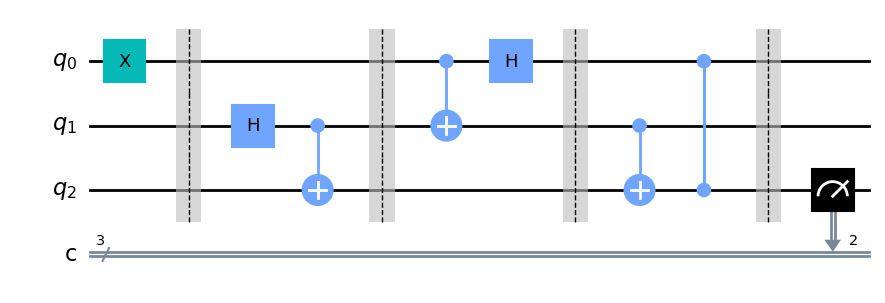

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def build_teleportation_circuit():
    """Builds and simulates a quantum teleportation protocol."""

    # We need 3 Qubits and 3 Classical Bits
    # q0: Alice's message to send
    # q1: Alice's half of the entangled pair
    # q2: Bob's half of the entangled pair
    qc = QuantumCircuit(3, 3)

    # --- 1. State Preparation ---
    # We apply an X gate to q0 to flip it to |1>.
    # This is the state we want to teleport to Bob.
    qc.x(0)
    qc.barrier()

    # --- 2. Create the Entangled Bell Pair ---
    # Create entanglement between Alice's q1 and Bob's q2
    qc.h(1)
    qc.cx(1, 2)
    qc.barrier()

    # --- 3. Alice's Operations ---
    # Alice entangles her message (q0) with her Bell qubit (q1)
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()

    # --- 4. Measurement and Bob's Corrections ---
    # Using the "Principle of Deferred Measurement", we can apply Bob's conditional
    # X and Z gates directly using quantum CNOT/CZ gates before the final measurement.
    # This is mathematically equivalent to classical conditional routing.

    qc.cx(1, 2) # If Alice's q1 is 1, apply X gate to Bob's q2
    qc.cz(0, 2) # If Alice's q0 is 1, apply Z gate to Bob's q2
    qc.barrier()

    # --- 5. Final Verification ---
    # Measure Bob's qubit (q2) to a classical bit to verify he received the |1>
    qc.measure(2, 2)

    # Run the simulation
    simulator = AerSimulator()
    job = simulator.run(qc, shots=1000)
    result = job.result()
    counts = result.get_counts(qc)

    print("--- Teleportation Results ---")
    print("Format: 'Bob_Alice1_Alice0'")
    print(f"Raw measurements: {counts}")

    # Check if Bob's bit (the furthest left in the string) is '1'
    bobs_results = [state[0] for state in counts.keys()]
    if all(bit == '1' for bit in bobs_results):
        print("\nSUCCESS! Bob successfully received the |1> state.")
    else:
        print("\nERROR: Teleportation failed.")

    # Draw the circuit schematic
    display(qc.draw('mpl', style='clifford'))

# Execute the protocol
build_teleportation_circuit()